# Startification

In [13]:
from sklearn.datasets import load_iris

data, target = load_iris(as_frame=True, return_X_y=True)

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(), LogisticRegression())

In [17]:
import numpy as np
from sklearn.model_selection import KFold

data_random = np.random.randn(9, 1)
cv = KFold(n_splits=3)
for train_index, test_index in cv.split(data_random):
    print("TRAIN:", train_index, "TEST:", test_index)

TRAIN: [3 4 5 6 7 8] TEST: [0 1 2]
TRAIN: [0 1 2 6 7 8] TEST: [3 4 5]
TRAIN: [0 1 2 3 4 5] TEST: [6 7 8]


- By defining three splits, we will use three samples for testing and six for training each time. 
- KFold does not shuffle by default. 
- It means that it will select the three first samples for the testing set at the first split, then the three next three samples for the second split, and the three next for the last split. 
- In the end, all samples have been used in testing at least once among the different splits.

In [20]:
from sklearn.model_selection import cross_validate

cv = KFold(n_splits=3)
results = cross_validate(model, data, target, cv=cv)
test_score = results["test_score"]
print(
    f"The average accuracy is {test_score.mean():.3f} ± {test_score.std():.3f}"
)

The average accuracy is 0.000 ± 0.000


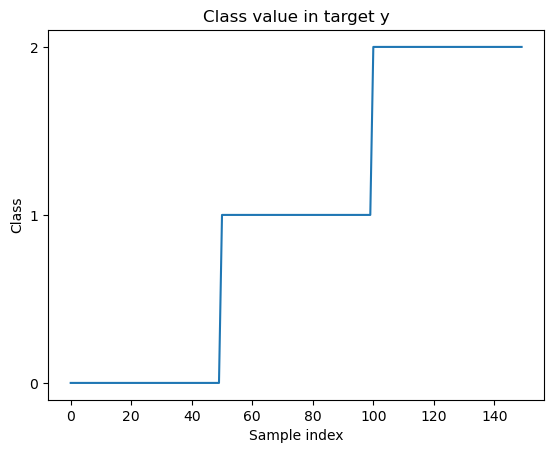

In [21]:
import matplotlib.pyplot as plt

target.plot()
plt.xlabel("Sample index")
plt.ylabel("Class")
plt.yticks(target.unique())
_ = plt.title("Class value in target y")

In [22]:
import pandas as pd

n_splits = 3
cv = KFold(n_splits=n_splits)

train_cv_counts = []
test_cv_counts = []
for fold_idx, (train_idx, test_idx) in enumerate(cv.split(data, target)):
    target_train, target_test = target.iloc[train_idx], target.iloc[test_idx]

    train_cv_counts.append(target_train.value_counts())
    test_cv_counts.append(target_test.value_counts())
    

In [23]:
train_cv_counts = pd.concat(
    train_cv_counts, axis=1, keys=[f"Fold #{idx}" for idx in range(n_splits)]
)
train_cv_counts.index.name = "Class label"
train_cv_counts

,Fold #0,Fold #1,Fold #2
Class label,,,
1,50.0,NaN,50.0
2,50.0,50.0,NaN
0,NaN,50.0,50.0


In [24]:
test_cv_counts = pd.concat(
    test_cv_counts, axis=1, keys=[f"Fold #{idx}" for idx in range(n_splits)]
)
test_cv_counts.index.name = "Class label"
test_cv_counts

,Fold #0,Fold #1,Fold #2
Class label,,,
0,50.0,NaN,NaN
1,NaN,50.0,NaN
2,NaN,NaN,50.0


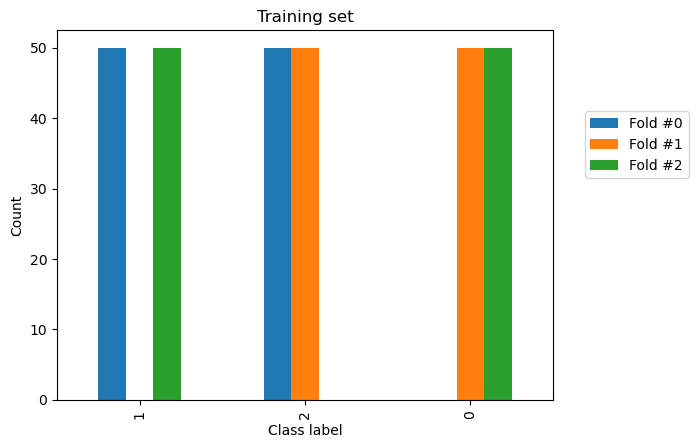

In [25]:
train_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Training set")

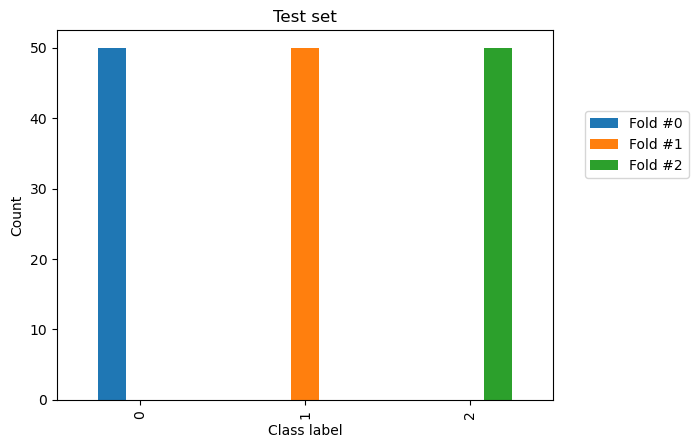

In [26]:
test_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Test set")

- in each fold, only two of the three classes are present in the training set and all samples of the remaining class is used as a test set. So our model is unable to predict this class that was unseen during the training stage.

In [27]:
cv = KFold(n_splits=3, shuffle=True, random_state=0)
results = cross_validate(model, data, target, cv=cv)
test_score = results["test_score"]
print(
    f"The average accuracy is {test_score.mean():.3f} ± {test_score.std():.3f}"
)

The average accuracy is 0.953 ± 0.009


In [28]:
train_cv_counts = []
test_cv_counts = []
for fold_idx, (train_idx, test_idx) in enumerate(cv.split(data, target)):
    target_train, target_test = target.iloc[train_idx], target.iloc[test_idx]

    train_cv_counts.append(target_train.value_counts())
    test_cv_counts.append(target_test.value_counts())
train_cv_counts = pd.concat(
    train_cv_counts, axis=1, keys=[f"Fold #{idx}" for idx in range(n_splits)]
)
test_cv_counts = pd.concat(
    test_cv_counts, axis=1, keys=[f"Fold #{idx}" for idx in range(n_splits)]
)
train_cv_counts.index.name = "Class label"
test_cv_counts.index.name = "Class label"

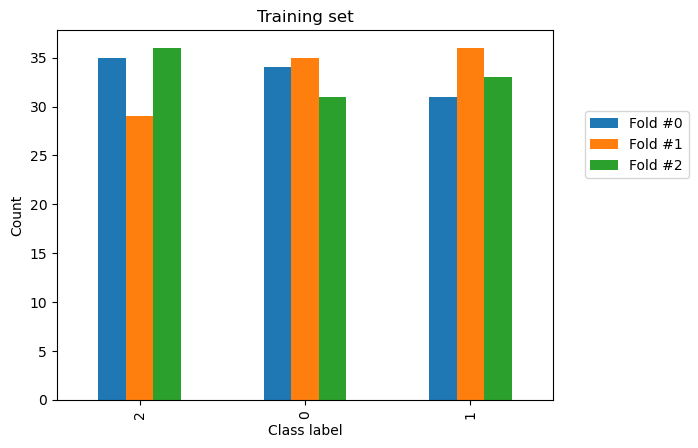

In [29]:
train_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Training set")

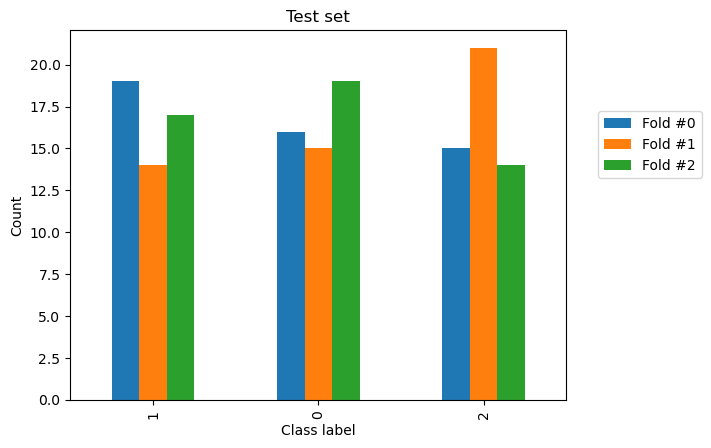

In [30]:
test_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Test set")

- neither the training and testing sets have the same class frequencies as our original dataset because the count for each class is varying a little.

- split our data by preserving the original class frequencies: we want to stratify our data by class

In [31]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=3)

In [32]:
results = cross_validate(model, data, target, cv=cv)
test_score = results["test_score"]
print(
    f"The average accuracy is {test_score.mean():.3f} ± {test_score.std():.3f}"
)

The average accuracy is 0.967 ± 0.009


In [33]:
train_cv_counts = []
test_cv_counts = []
for fold_idx, (train_idx, test_idx) in enumerate(cv.split(data, target)):
    target_train, target_test = target.iloc[train_idx], target.iloc[test_idx]

    train_cv_counts.append(target_train.value_counts())
    test_cv_counts.append(target_test.value_counts())
train_cv_counts = pd.concat(
    train_cv_counts, axis=1, keys=[f"Fold #{idx}" for idx in range(n_splits)]
)
test_cv_counts = pd.concat(
    test_cv_counts, axis=1, keys=[f"Fold #{idx}" for idx in range(n_splits)]
)
train_cv_counts.index.name = "Class label"
test_cv_counts.index.name = "Class label"

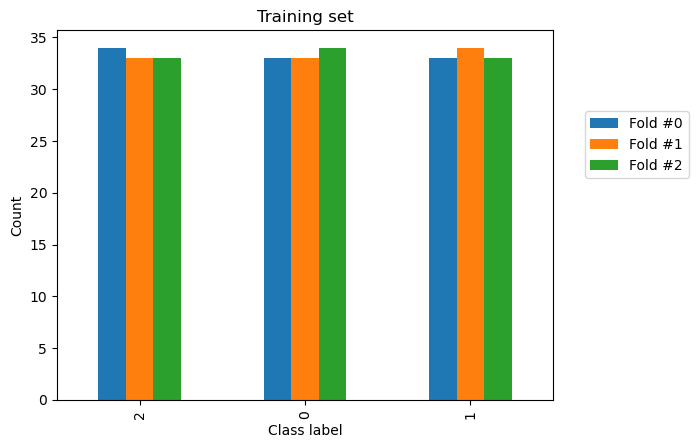

In [34]:
train_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Training set")

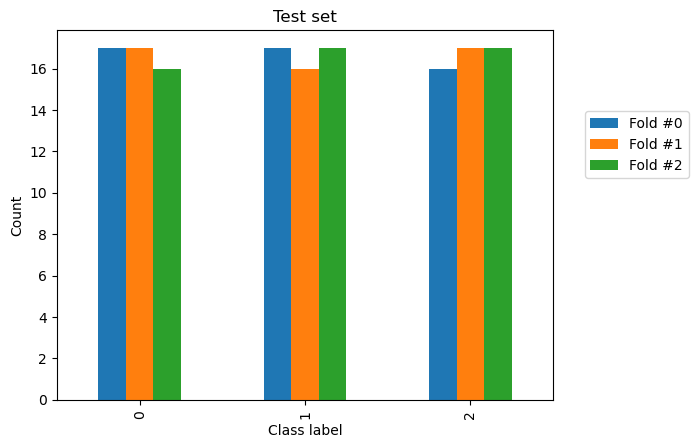

In [35]:
test_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Test set")

-  the class counts are very close both in the train set and the test set. The difference is due to the small number of samples in the iris dataset.

- In conclusion, this is a good practice to use stratification within the cross-validation framework when dealing with a classification problem.